In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# dataset 1

In [22]:
df= pd.read_csv("homework_4.1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Z       5000 non-null   int64  
 1   W       5000 non-null   float64
 2   X       5000 non-null   float64
 3   Y       5000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 156.4 KB


In [23]:
y_diff = (
    df[df["Z"]==1]["Y"].mean()
    - df[df["Z"]==0]["Y"].mean()
)

x_diff = (
    df[df["Z"]==1]["X"].mean()
    - df[df["Z"]==0]["X"].mean()
)

effect = y_diff / x_diff

print(effect)

1.5618587073765748


In [24]:
import pandas as pd
import numpy as np

# Example: df has columns Z, W, X, Y

num_bins = 10

df["W_bin"] = pd.cut(df["W"], bins=num_bins)

bin_effects = []

for w_bin, group in df.groupby("W_bin"):
    
    # Need both Z = 0 and Z = 1 in the bin
    if group["Z"].nunique() < 2:
        continue
    
    y_z1 = group.loc[group["Z"] == 1, "Y"].mean()
    y_z0 = group.loc[group["Z"] == 0, "Y"].mean()
    
    x_z1 = group.loc[group["Z"] == 1, "X"].mean()
    x_z0 = group.loc[group["Z"] == 0, "X"].mean()
    
    y_diff = y_z1 - y_z0
    x_diff = x_z1 - x_z0
    
    # Avoid dividing by zero or tiny values
    if abs(x_diff) > 1e-8:
        effect = y_diff / x_diff
        bin_effects.append(effect)

average_effect = np.mean(bin_effects)

print("Bin-level effects:", bin_effects)
print("Average IV effect:", average_effect)

Bin-level effects: [np.float64(1.1461665892943127), np.float64(1.838724543226674), np.float64(1.4396279263949772), np.float64(1.5340022539220801), np.float64(1.572353767614793), np.float64(1.5084101827247918), np.float64(1.3113519208931754), np.float64(1.5149647439088125), np.float64(-3.688723429435266)]
Average IV effect: 0.9085420553938168


/var/folders/l5/1dbkpbtn1md89c9k23nrcj9c0000gn/T/ipykernel_88028/998522501.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for w_bin, group in df.groupby("W_bin"):


# dataset 2

In [25]:
df_a= pd.read_csv("homework_4.2.a.csv")
df_b= pd.read_csv("homework_4.2.b.csv")
df_a.info()
df_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   X       100000 non-null  float64
 1   Y       100000 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.5 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   X2      100000 non-null  float64
 1   Y2      100000 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.5 MB


In [26]:
import statsmodels.formula.api as smf

cutoff = 80

df_a["After"] = (df_a["X"] >= cutoff).astype(int)
df_a["X_centered"] = df_a["X"] - cutoff

model_a = smf.ols(
    "Y ~ X_centered + After + X_centered:After",
    data=df_a
).fit()

print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3300.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:15:08   Log-Likelihood:                -67412.
No. Observations:              100000   AIC:                         1.348e+05
Df Residuals:                   99996   BIC:                         1.349e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3050      0.004  

In [27]:
df_b["After"] = (df_b["X2"] >= cutoff).astype(int)
df_b["X_centered"] = df_b["X2"] - cutoff

model_b = smf.ols(
    "Y2 ~ X_centered + After + X_centered:After",
    data=df_b
).fit()

print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     6360.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:15:08   Log-Likelihood:                -45123.
No. Observations:              100000   AIC:                         9.025e+04
Df Residuals:                   99996   BIC:                         9.029e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.7023      0.003  

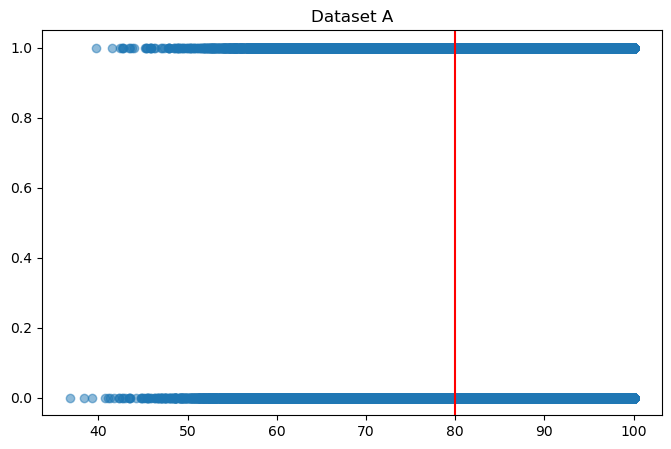

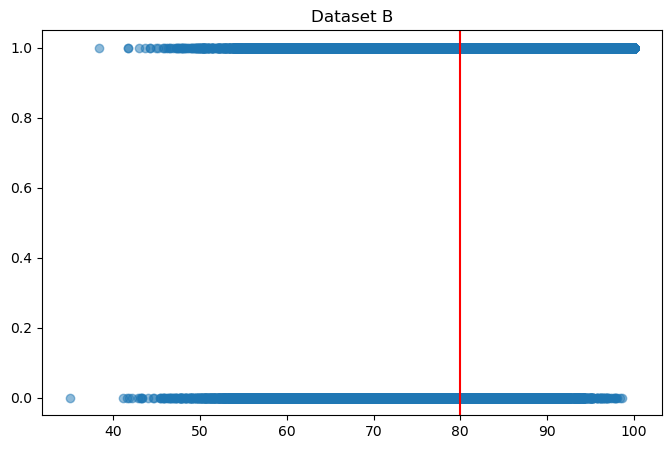

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_a["X"], df_a["Y"], alpha=0.5)
plt.axvline(80, color="red")
plt.title("Dataset A")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df_b["X2"], df_b["Y2"], alpha=0.5)
plt.axvline(80, color="red")
plt.title("Dataset B")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


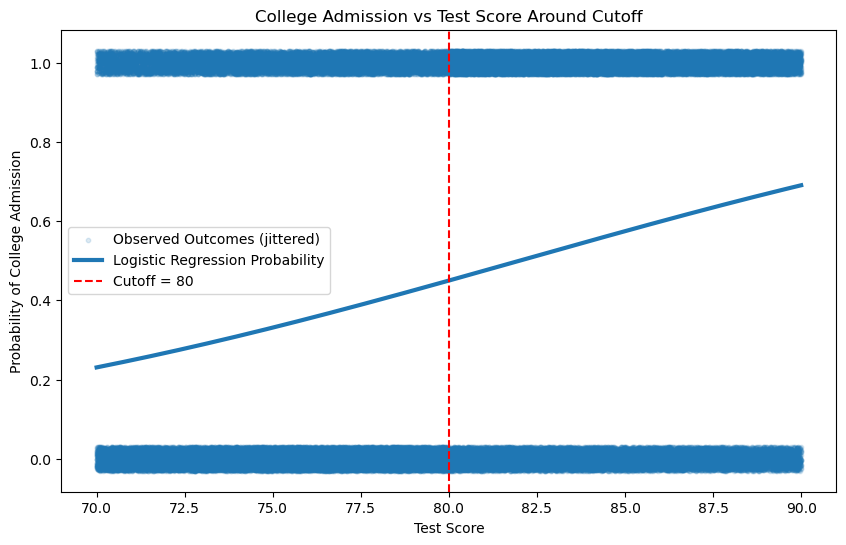

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Assuming Dataset A
df = df_a.copy()

# Focus on scores near the cutoff
df_local = df[(df["X"] >= 70) & (df["X"] <= 90)].copy()

# Fit logistic regression
X = df_local[["X"]]
y = df_local["Y"]

logit = LogisticRegression()
logit.fit(X, y)

# Smooth probability curve
x_grid = np.linspace(70, 90, 500).reshape(-1, 1)
p_hat = logit.predict_proba(x_grid)[:, 1]

# Jitter the actual outcomes
np.random.seed(42)
y_jitter = df_local["Y"] + np.random.uniform(-0.03, 0.03, len(df_local))

# Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df_local["X"],
    y_jitter,
    alpha=0.15,
    s=10,
    label="Observed Outcomes (jittered)"
)

plt.plot(
    x_grid,
    p_hat,
    linewidth=3,
    label="Logistic Regression Probability"
)

plt.axvline(
    80,
    color="red",
    linestyle="--",
    label="Cutoff = 80"
)

plt.xlabel("Test Score")
plt.ylabel("Probability of College Admission")
plt.title("College Admission vs Test Score Around Cutoff")
plt.legend()
plt.show()